In [133]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [134]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\08.checkm

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\08.checkm


In [135]:
df = pd.read_csv('quality_report_merged_drep.csv')
df

,Genome,Completeness,Contamination,Genome_Size,Genome_Size_Mbp
0,C01.024.fa,100.00,0.46,3491366,3.491366
1,C01_concoct.162.fa,100.00,0.21,5051852,5.051852
2,C01.005.fa,99.97,0.24,1972376,1.972376
3,C01_concoct.147.fa,99.85,5.54,3785308,3.785308
4,C01_metabat2.bins.98.fa,99.69,1.85,3738366,3.738366
...,...,...,...,...,...
290,V07_concoct.5.fa,99.99,0.29,7095029,7.095029
291,V07.002.fa,99.98,0.14,1973510,1.973510
292,V08.001.fa,100.00,0.09,4748417,4.748417
293,V08.002.fa,99.98,0.24,2017138,2.017138


In [136]:
# =========================
# Required columns check
# =========================
required = ["Genome", "Completeness", "Contamination", "Genome_Size_Mbp"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Numeric conversion
for c in ["Completeness", "Contamination", "Genome_Size_Mbp"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Completeness", "Contamination", "Genome_Size_Mbp"]).copy()
df

,Genome,Completeness,Contamination,Genome_Size,Genome_Size_Mbp
0,C01.024.fa,100.00,0.46,3491366,3.491366
1,C01_concoct.162.fa,100.00,0.21,5051852,5.051852
2,C01.005.fa,99.97,0.24,1972376,1.972376
3,C01_concoct.147.fa,99.85,5.54,3785308,3.785308
4,C01_metabat2.bins.98.fa,99.69,1.85,3738366,3.738366
...,...,...,...,...,...
290,V07_concoct.5.fa,99.99,0.29,7095029,7.095029
291,V07.002.fa,99.98,0.14,1973510,1.973510
292,V08.001.fa,100.00,0.09,4748417,4.748417
293,V08.002.fa,99.98,0.24,2017138,2.017138


In [137]:
# =========================
# MAG quality classification
# =========================
def classify_mag(row):
    comp = row["Completeness"]
    cont = row["Contamination"]
    if comp >= 90 and cont < 5:
        return "High"
    elif comp >= 50 and cont < 10:
        return "Medium"
    else:
        return "Low"

df["Quality"] = df.apply(classify_mag, axis=1)

# Color grouping
# Group 열이 있으면 Group 기준, 없으면 Quality 기준으로 색 지정
hue_col = "Group" if "Group" in df.columns else "Quality"

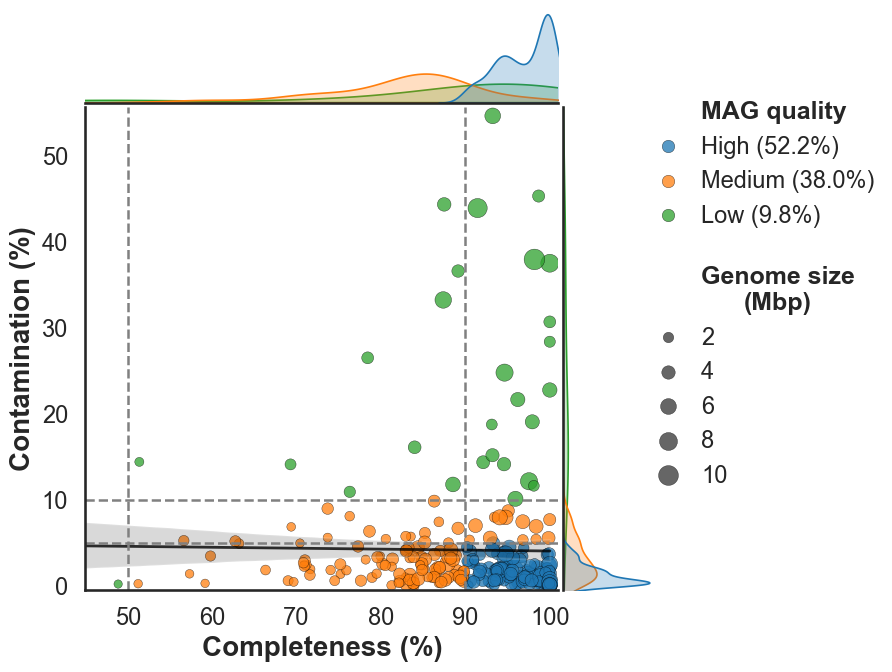

In [138]:
# ========================= # Plot # =========================
sns.set_context("talk")
sns.set_style("white")

g = sns.JointGrid(data=df, x="Completeness", y="Contamination", height=7, ratio=5, space=0.05)

# Main scatter
sns.scatterplot(data=df, x="Completeness", y="Contamination", hue=hue_col, size="Genome_Size_Mbp", sizes=(30, 220), alpha=0.75, edgecolor="k", linewidth=0.3, ax=g.ax_joint)

# Trend
sns.regplot(data=df, x="Completeness", y="Contamination", 
#            lowess=True, 
            scatter=False, color="k", line_kws={'linewidth': 2, 'alpha': 0.8}, ax=g.ax_joint)

# Marginal KDEs
# 표본 수가 적거나 singular covariance 문제가 있으면 hist로 fallback
try:
    sns.kdeplot(data=df, x="Completeness", hue=hue_col, fill=True, common_norm=False, alpha=0.25, linewidth=1.2, legend=False, ax=g.ax_marg_x)
    sns.kdeplot(data=df, y="Contamination", hue=hue_col, fill=True, common_norm=False, alpha=0.25, linewidth=1.2, legend=False, ax=g.ax_marg_y)
except Exception:
    sns.histplot(data=df, x="Completeness", hue=hue_col, element="step", stat="density", common_norm=False, legend=False, ax=g.ax_marg_x)
    sns.histplot(data=df, y="Contamination", hue=hue_col, element="step", stat="density", common_norm=False, legend=False, ax=g.ax_marg_y)

# Quality cutoff lines
g.ax_joint.axvline(50, linestyle="--", linewidth=1.8, color="gray")
g.ax_joint.axvline(90, linestyle="--", linewidth=1.8, color="gray")
g.ax_joint.axhline(5, linestyle="--", linewidth=1.8, color="gray")
g.ax_joint.axhline(10, linestyle="--", linewidth=1.8, color="gray")

# Labels
g.ax_joint.set_xlabel("Completeness (%)", fontsize=20, fontweight="bold")
g.ax_joint.set_ylabel("Contamination (%)", fontsize=20, fontweight="bold")

g.ax_joint.tick_params(axis='both', labelsize=17)

# Axis limits
g.ax_joint.set_xlim(45, 101) #Edit
g.ax_joint.set_ylim(-0.5, max(10, df["Contamination"].max() + 1))

# =========================
# Legend formatting
# =========================
handles, labels = g.ax_joint.get_legend_handles_labels()

# 1-1) legend에 표시될 이름 바꾸기
#label_map = {'Quality': 'MAG quality', 
#             'Genome_Size_Mbp': '\nGenome size\n(Mbp)', 
#             }

# 1-2) legend -> MAG quality별 %로
# MAG quality 비율 계산
quality_pct = (df["Quality"].value_counts(normalize=True) * 100).to_dict()

label_map = {
    'Quality': 'MAG quality',
    'Genome_Size_Mbp': '\nGenome size\n(Mbp)',

    # Quality category 이름 + 퍼센트 추가
    'High': f'High ({quality_pct.get("High", 0):.1f}%)', 
    'Medium': f'Medium ({quality_pct.get("Medium", 0):.1f}%)', 
    'Low': f'Low ({quality_pct.get("Low", 0):.1f}%)', 
    }


new_labels = [label_map.get(str(lab), str(lab)) for lab in labels]

# 2) legend 생성
leg = g.ax_joint.legend(handles=handles, labels=new_labels, bbox_to_anchor=(1.17, 1.03), loc="upper left", frameon=False, fontsize=15, handletextpad=0.6, labelspacing=0.55, borderaxespad=0)
leg._legend_box.align = 'left'

# 3) section header
header_names = {'MAG quality', 
                '\nGenome size\n(Mbp)', 
                }

for txt in leg.get_texts():
    txt.set_ha('center')
    
    if txt.get_text() in header_names:
        txt.set_fontweight("bold")
        txt.set_fontsize(18)
    else:
        txt.set_fontsize(17) # txt.set_fontweight("bold") #Edit: 전체 legend 항목까지 볼드체로 하고 싶으면 주석해제 plt.tight_layout()

plt.tight_layout()

plt.savefig('MAG_quality_plot.png', dpi=500, bbox_inches='tight')
plt.show()